### seaborn.relplot

`relplot` is a figure-level interface for drawing relational plots onto a **FacetGrid**. The `kind` parameter selects the underlying axes-level function to use:

- kind="scatter" uses `scatterplot()`
- kind="line" uses `lineplot()`

Different subsets of the data can be created using the `hue`, `size` and `style` parameters which control visual semantics that identify the different subsets.

<pre style="font-family:'Courier New';font-size:1.0em;">
<span style="color:orange;font-weight:600;">sns</span>.<span style="color:darkblue;font-weight:600;">relplot</span>(
    data,        # input data structure
    x,           # variables that specify
    y,           # positions on the x and y axes.
    hue,         # grouping variable that produces elements with different colors.
    size,        #                             ""                different sizes.
    style,       #                             ""                different styles.
    sizes,       # determines how sizes are chosen when <b>size</b> is used:a list 
                 # provides sizes for all values; can also be a tuple (min, max).
    weights,     # values in a column used to compute weighted estimations.
    row, col,    # variables that define subsets to plot on different facets.
    col_wrap,    # wrap the column variable at this width so that the column facets span multiple rows.
    palette,     # method for choosing the colors to use when mapping the <b>hue</b> semantic.
    kind         # the kind of plot to draw: "scatter" or "line".
)
</pre>

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


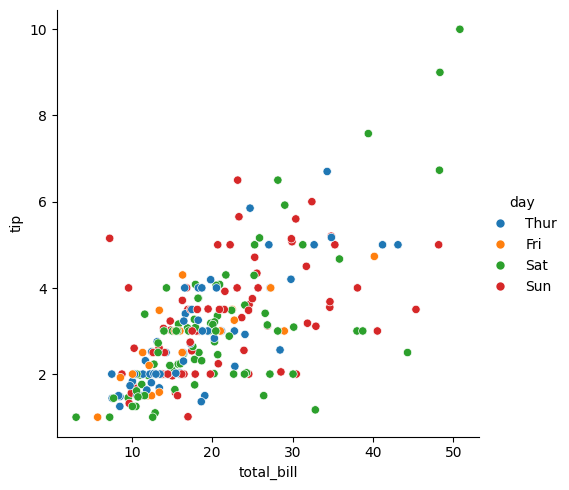

In [2]:
sns.relplot(data=tips, x="total_bill", y="tip", hue="day")
plt.show()

`col` creates multiple subplots arranged across the columns of the grid.

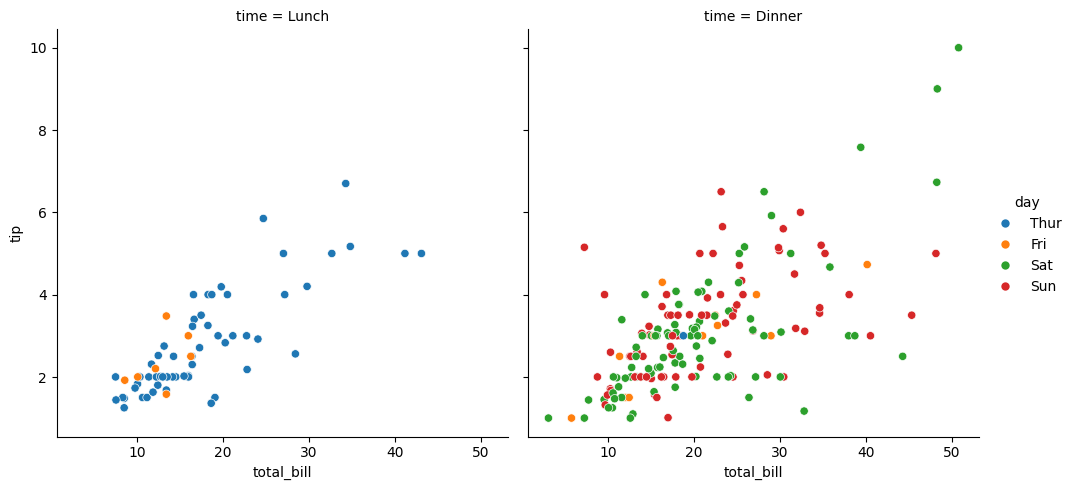

In [3]:
sns.relplot(data=tips, x="total_bill", y="tip", hue="day", col="time")
plt.show()

Different values can be assigned to facet on both the columns and rows:

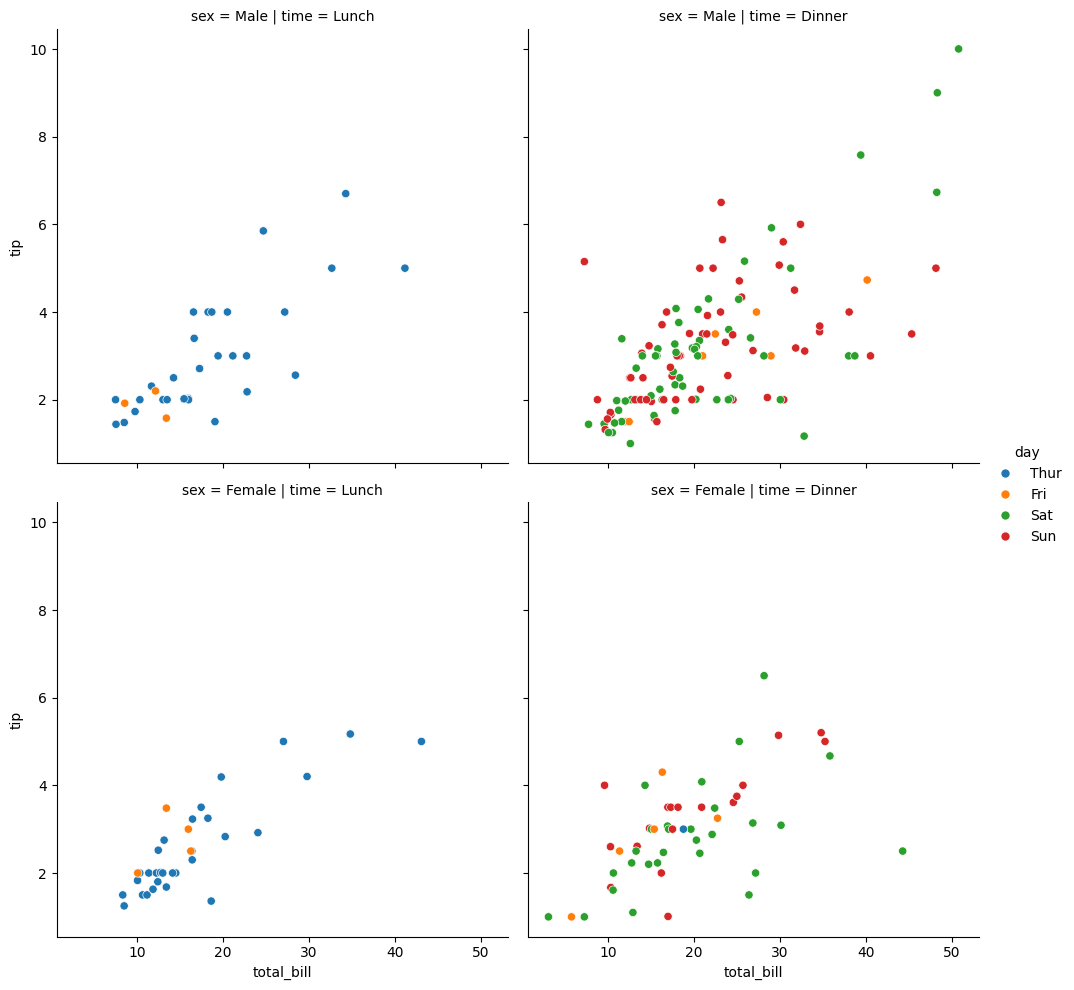

In [4]:
sns.relplot(data=tips, x="total_bill", y="tip", hue="day", col="time", row="sex")
plt.show()

If the variable assigned to `col` has many levels, it can be **wrapped** across multiple rows:<br/>
For example the variable "day" assigned to `col` below, has levels: Thur, Fri, Sat and Sun.<br/>
So we instruct seaborn to wrap when it reaches the width of 2 facets.

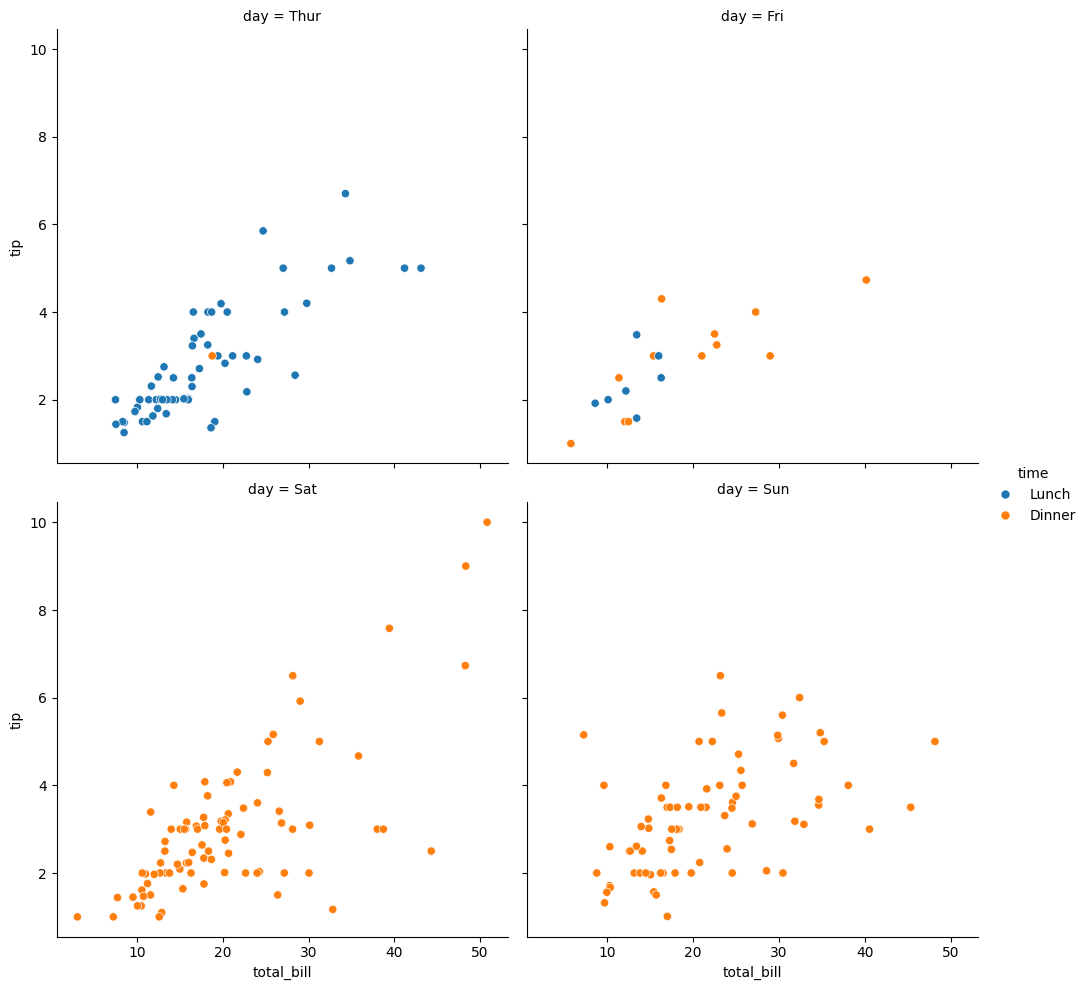

In [5]:
sns.relplot(data=tips, x="total_bill", y="tip", hue="time", col="day", col_wrap=2)
plt.show()

Assigning multiple semantic variables (hue, size, style) can show **multi-dimensional** relationships but may produce an **overly-complicated** plot.

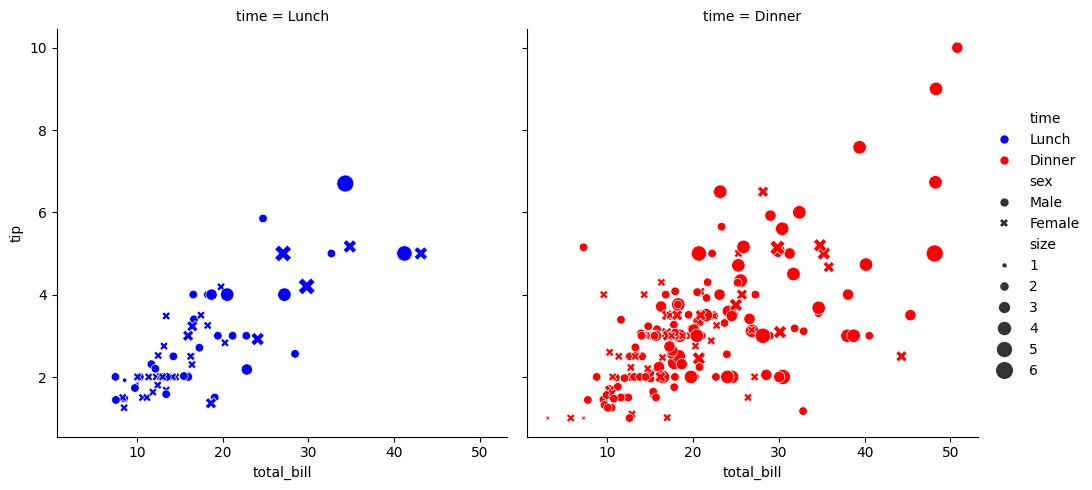

In [11]:
sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    col="time",
    hue="time",  # multiple
    size="size",  # semantic
    style="sex",  # variables
    palette=["b", "r"],
    sizes=(10, 150),
)
plt.show()

When there is a **natural continuity** in one of the variables, it makes more sense to display lines instead of points. So we set `kind="line"`.

In [12]:
fmri = sns.load_dataset("fmri")
fmri.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


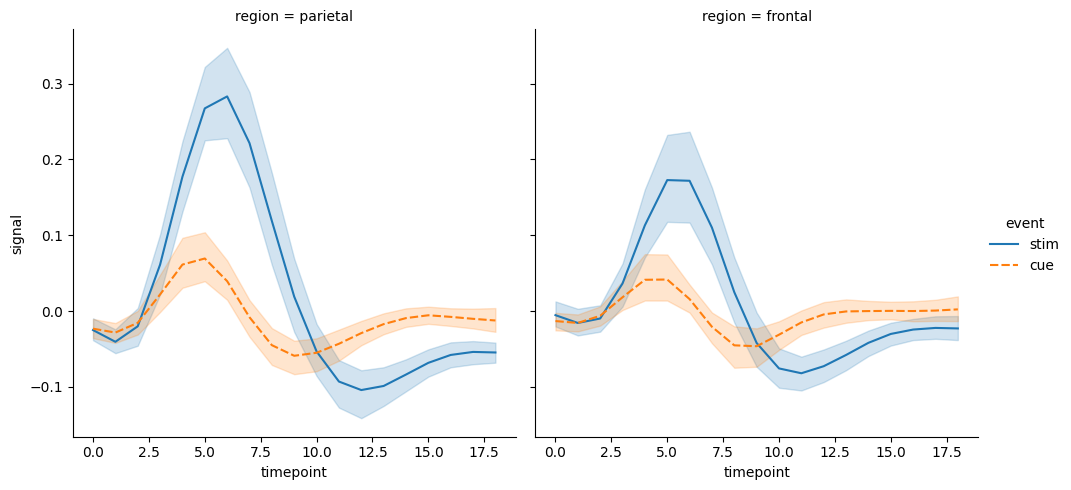

In [13]:
sns.relplot(
    data=fmri,
    x="timepoint",
    y="signal",
    col="region",
    hue="event",
    style="event",
    kind="line",
)
plt.show()

The size and shape of the figure is parameterized by the `height` and `aspect` ratio of each individual facet:

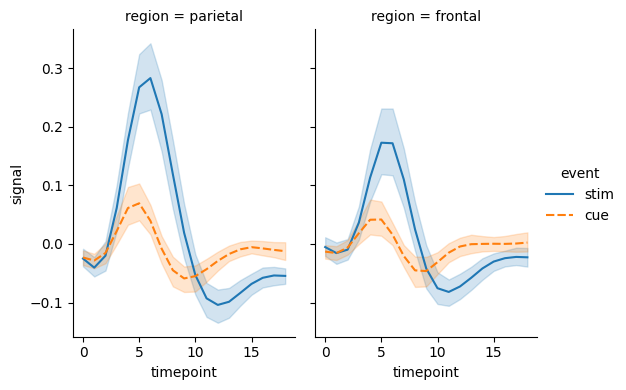

In [14]:
sns.relplot(
    data=fmri,
    x="timepoint",
    y="signal",
    hue="event",
    style="event",
    col="region",
    height=4,
    aspect=0.7,
    kind="line",
)
plt.show()

`relplot` returns a `FacetGrid` object with several methods allowing for setting title, labels, etc.

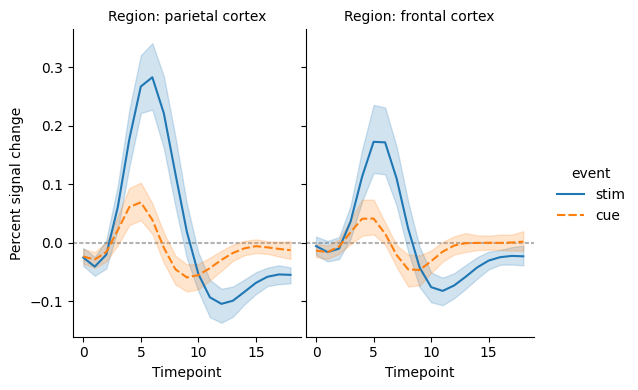

In [23]:
# fmt: off
facet_grid = sns.relplot(
    data=fmri,
    x="timepoint",
    y="signal",
    hue="event",
    style="event",
    col="region",
    height=4,
    aspect=0.7,
    kind="line",
)
(
    facet_grid.map(plt.axhline, y=0, color="0.7", dashes=(2, 1), zorder=0)
              .set_axis_labels("Timepoint","Percent signal change")
              .set_titles("Region: {col_name} cortex")
              .tight_layout(w_pad=0)
)
plt.show()

It's also possible to use **wide-form** data with `relplot`.<br/>
Faceting is not an option in this case, but the plot will still take advantage of the external legend offered by `FacetGrid`.

In [ ]:
# fmt: off
flights_wide = (
    sns.load_dataset("flights")
       .pivot(index="year",columns="month",values="passengers")
)

In [31]:
flights_wide.head()

month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
1949,112,118,132,129,121,135,148,148,136,119,104,118
1950,115,126,141,135,125,149,170,170,158,133,114,140
1951,145,150,178,163,172,178,199,199,184,162,146,166
1952,171,180,193,181,183,218,230,242,209,191,172,194
1953,196,196,236,235,229,243,264,272,237,211,180,201


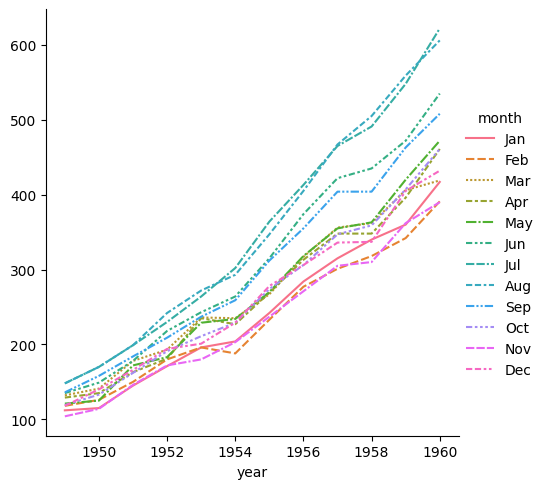

In [32]:
sns.relplot(data=flights_wide, kind="line")
plt.show()